In [1]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split 
import emcee #für bayes-infereznz
import scipy.optimize as op 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on devie: {device}")

np.random.seed(42)
torch.manual_seed(42)

Running on devie: cpu


In [3]:
def inverse_power_model(t, K, n):
    # das physikalische Modell aus der Dessertaion 
    return K * (t ** -n)

def exp_model(t, K, n):
    return K * (exp(-n * t))

def exp_3_param_model(t, K, N, M):
    return K * (exp(-n * t)) + M

In [4]:
#k_list = []
#n_list = []
#life_list = []

#for i in range(1000): 
    #K_sim = np.random.uniform(400, 600)
    #n_sim = np.random.uniform(0.015, 0.050)

    #k_list.append(K_sim)
    #n_list.append(n_sim)

    #limit_pdiv = 350.0
    #life_sim = int((limit_pdiv/K_sim) ** (-1/n_sim))
    #life_list.append(life_sim)
#print(k_list)
#print(n_list)
#print(life_list)

In [5]:
#testing 
#new_list = []
#for i in life_list: 
 #   if i > 200 and i > 4000: 
  #      print(i)
   #     new_list.append(i)
#print(f"len of new list is {len(new_list)}")

In [6]:
def generate_synthetic_motor_data(n_samples=5000):
    all_curves = []
    all_lifetimes = []

    # Grenzen für K aus der dessertation
    K_min, K_max = 400, 600
    #Grenzen für die Lebensdauer
    Life_min, Life_max = 250, 4000
    #Failure Threshold
    LIMIT_PDIV = 350.0

    for _ in range(n_samples): 
        K_sim = np.random.uniform(K_min, K_max)
        target_life = np.random.uniform(Life_min, Life_max)

        # nach n umstellen -> 350 = K * life **(-n) --> n = -ln(350/K) / ln(life)
        n_sim = -np.log(LIMIT_PDIV / K_sim) / np.log(target_life)

        # Kurve generieren
        life_sim_int = int(target_life)
        t = np.linspace(1, life_sim_int, life_sim_int)
        pdiv_curve = inverse_power_model(t, K_sim, n_sim)

        #Rauschen hinzufügne 
        noise_level = np.random.uniform(1.0, 3.0)
        noise = np.random.normal(0, noise_level, size=pdiv_curve.shape)
        pdiv_curve_noisy = pdiv_curve + noise

        all_curves.append(pdiv_curve_noisy)
        all_lifetimes.append(life_sim_int)

    return all_curves, np.array(all_lifetimes)

In [7]:
#Daten generieren 
raw_curves, raw_lifetimes = generate_synthetic_motor_data(n_samples=5000)

print(f"Anzahl Samples: {len(raw_lifetimes)}")
print(f"Min Lebensdauer: {min(raw_lifetimes)}")
print(f"Max Lebensdauer: {max(raw_lifetimes)}")

Anzahl Samples: 5000
Min Lebensdauer: 250
Max Lebensdauer: 3998


/var/folders/vf/d7d1stc54w3dmyc5xs67xw0m0000gn/T/ipykernel_31560/1312151721.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


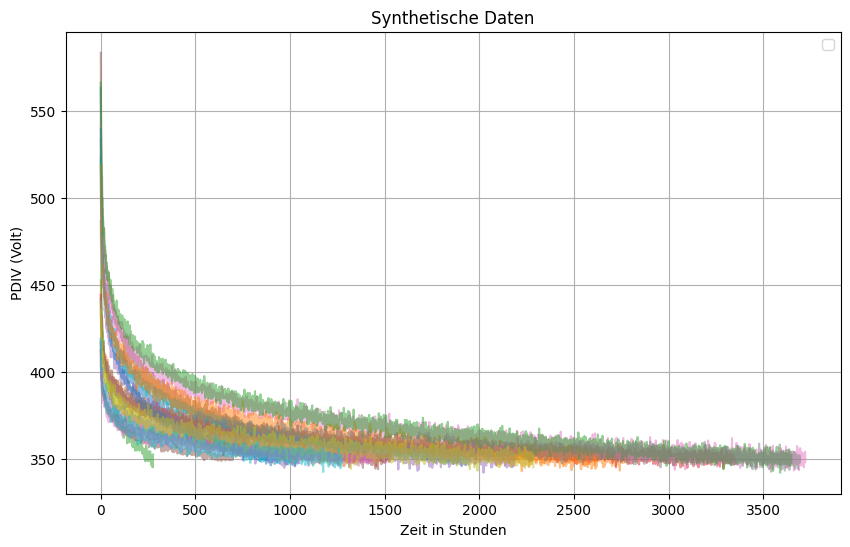

In [8]:
plt.figure(figsize=(10,6))

for i in np.random.choice(len(raw_curves), 20, replace=False):
    plt.plot(raw_curves[i], alpha = 0.5)

plt.grid(True)
plt.xlabel("Zeit in Stunden")
plt.ylabel("PDIV (Volt)")
plt.title("Synthetische Daten")
plt.legend()
plt.show()

In [9]:
#Parameter
INPUT_WINDOW = 300

X_data = []
y_data = []
valid_full_curves = [] #hier die kompletten Kurven 

#Slicing Loop (20%)
for i, curve in enumerate(raw_curves):
    # nur Motoren nehemen, deren Life > Input_window
    if len(curve) > INPUT_WINDOW: 
        #Input: die ersten n Datenpunkte
        input_seq = curve[:INPUT_WINDOW]
        #Output: Die echte Lebensdauer
        target_life = raw_lifetimes[i]

        X_data.append(input_seq)
        y_data.append(target_life)
        valid_full_curves.append(curve)

X_data = np.array(X_data)
y_data = np.array(y_data)

#Skalierung
scaler_X = MinMaxScaler()
X_data_flat = X_data.reshape(-1,1)
scaler_X.fit(X_data_flat)
X_scaled = scaler_X.transform(X_data_flat).reshape(X_data.shape)

# Reshape (Batch, Channels, Sequence_Length)
X_final = X_scaled.reshape(-1, 1, INPUT_WINDOW)
y_final = y_data.reshape(-1, 1).astype(np.float32)

#Train/Test Split 
X_train, X_test, y_train, y_test, curves_train, curves_test = train_test_split(X_final, y_final, valid_full_curves, test_size= 0.2, random_state=42)

In [10]:
class MotorDataset(Dataset):
    def __init__(self, X, y): 
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MotorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(MotorDataset(X_test, y_test), batch_size=32, shuffle=False)

print(f"Trainingdaten Shape: {X_train.shape}")
print(f"Testdaten Shape: {X_test.shape}")
print(f"Anzahl voller Kurven im Testset: {len(curves_test)}")

Trainingdaten Shape: (3938, 1, 300)
Testdaten Shape: (985, 1, 300)
Anzahl voller Kurven im Testset: 985


In [11]:
#CNN Modell 

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride !=1 or in_channels != out_channels: 
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self,x): 
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return out

class ResCNN(nn.Module):
    def __init__(self):
        super(ResCNN, self).__init__()
        # Input Channels: 1 (PDIV Jurve)
        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu = nn.ReLU(inplace=True)

        #Residual Blocks
        self.layer1 = self._make_layer(16, 16, 2, stride=1)
        self.layer2 = self._make_layer(16, 32, 2, stride=2)
        self.layer3 = self._make_layer(32, 64, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # Fully connected layer for Regression Output(Lebensdauer)
        self.fc = nn.Linear(64, 1)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        layers.append(ResBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResBlock(out_channels, out_channels))
        return nn.Sequential(*layers)


    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
        
        

In [12]:
# Modell

model = ResCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

Starte Training:
Epoch 10/150, Train Loss: 2873209.3, Val Loss: 4008927.9
Epoch 20/150, Train Loss: 464972.6, Val Loss: 686099.0
Epoch 30/150, Train Loss: 121828.8, Val Loss: 626575.1
Epoch 40/150, Train Loss: 67798.4, Val Loss: 81402.1
Epoch 50/150, Train Loss: 60877.7, Val Loss: 306585.1
Epoch 60/150, Train Loss: 53842.6, Val Loss: 122407.9
Epoch 70/150, Train Loss: 60394.8, Val Loss: 57835.0
Epoch 80/150, Train Loss: 48080.4, Val Loss: 43051.5
Epoch 90/150, Train Loss: 40021.5, Val Loss: 15668.3 -> Saved best Model
Epoch 100/150, Train Loss: 48125.2, Val Loss: 42401.4
Epoch 110/150, Train Loss: 47042.5, Val Loss: 14217.0 -> Saved best Model
Epoch 120/150, Train Loss: 52048.3, Val Loss: 21708.9
Epoch 130/150, Train Loss: 56828.7, Val Loss: 41672.7
Epoch 140/150, Train Loss: 45574.3, Val Loss: 18068.2
Epoch 150/150, Train Loss: 51105.4, Val Loss: 28804.4
Training beendet, Bestes Modell (Val Loss: 14217.0):
Bestes Modell geladen


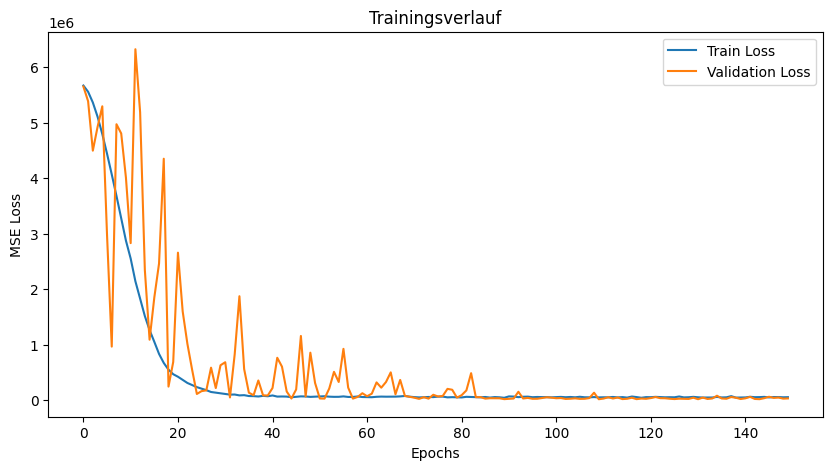

In [13]:
#Training
EPOCHS = 150
train_losses = []
test_losses = []
best_val_loss = float("inf")

print("Starte Training:")

for epoch in range(EPOCHS):
    #Train
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    #Validierung
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = val_loss / len(test_loader.dataset)
    test_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    #Checkpointing
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        # Gewichte in einer Datei speichern .pth
        torch.save(model.state_dict(), "best_motor_model.pth")
        save_msg = " -> Saved best Model"
    else:
        save_msg = ""
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {epoch_loss:.1f}, Val Loss: {epoch_val_loss:.1f}{save_msg}")


#Modell Laden 
print(f"Training beendet, Bestes Modell (Val Loss: {best_val_loss:.1f}):")
model.load_state_dict(torch.load("best_motor_model.pth"))
print("Bestes Modell geladen")

#plotten
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Validation Loss")
#
best_epoch = np.argmin(test_losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Trainingsverlauf")
plt.legend()
plt.show()

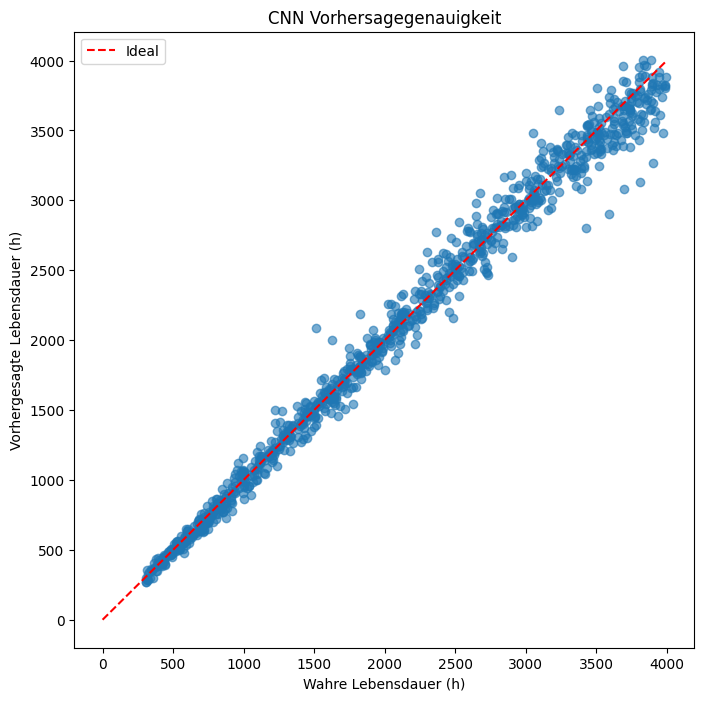

In [14]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs)
        predictions.extend(preds.cpu().numpy())
        actuals.extend(labels.numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

plt.figure(figsize=(8,8))
plt.scatter(actuals, predictions, alpha=0.6)
plt.plot([0, max(actuals)], [0, max(actuals)], "r--", label="Ideal")
plt.xlabel("Wahre Lebensdauer (h)")
plt.ylabel("Vorhergesagte Lebensdauer (h)")
plt.title("CNN Vorhersagegenauigkeit")
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"R2 Score: {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R2 Score: 0.9877
MSE: 14217.00
RMSE: 119.24


In [16]:
sample_idx = 2 # das hier ändern um andere Motoren zu prüfen
input_seq_tensor = torch.tensor(X_test[sample_idx]).unsqueeze(0).float().to(device)
cnn_predicted_lifetime= model(input_seq_tensor).item()

#originale Messdaten der ersten 200 Stunden (unskaliert)
input_seq_scaled = X_test[sample_idx].flatten()
input_seq_real = scaler_X.inverse_transform(input_seq_scaled.reshape(-1,1)).flatten()
t_observed = np.arange(1, INPUT_WINDOW + 1) #Zeit 1 bis 200

print(f"CNN Vorhersage Lebensdauer: {cnn_predicted_lifetime:.1f} h")
print(f"Wahre Lebensdauer: {y_test[sample_idx].item():.1f} h")

CNN Vorhersage Lebensdauer: 471.0 h
Wahre Lebensdauer: 472.0 h


In [17]:
#Bayes

#Log-Likelihood

def log_likelihood(theta, t, y_obs, y_err):
    K, n = theta
    model_vals = inverse_power_model(t, K, n)
    sigma2 = y_err**2
    return -0.5 * np.sum((y_obs - model_vals)**2 / sigma2 + np.log(sigma2))

#CNN-Ergebnis als log-prior
def log_prior(theta, predicted_life):
    K, n = theta
    #Grenzen (physikalisch plausibel): 
    if not (200 < K < 800 and 0.001 < n < 0.2):
        return -np.inf
    expected_end_pdiv = 350.0
    model_end_pdiv = inverse_power_model(predicted_life, K, n)

    #Gausian Prior um den Endpunkt
    return -0.5 * ((model_end_pdiv - expected_end_pdiv) / 50.0)**2

#Log-Probability (Posterior)
def log_probability(theta, t, y_obs, y_err, predicted_life): 
    lp = log_prior(theta, predicted_life)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y_obs, y_err)


In [18]:
#MCMC
#Startwerte (K, n)
initial_guess = [500, 0.03]
n_walkers = 32
ndim = 2

#Initialisierung der Walker um den Startpunkt
pos =  initial_guess + 1e-4 * np.random.randn(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(t_observed, input_seq_real, 2.0, cnn_predicted_lifetime))

print("Starte MCMC Sampling:")
sampler.run_mcmc(pos, 2000, progress=True)

#Ergebnisse extrahieren (die ersten 500 Schritte verwerfenm, als Burn in)
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)
K_median, n_median = np.median(flat_samples, axis=0)

print(f"Gefundene K und n: K= {K_median:.2f}, n= {n_median:.4f}")

You must install the tqdm library to use progress indicators with emcee


Starte MCMC Sampling:
Gefundene K und n: K= 508.25, n= 0.0607


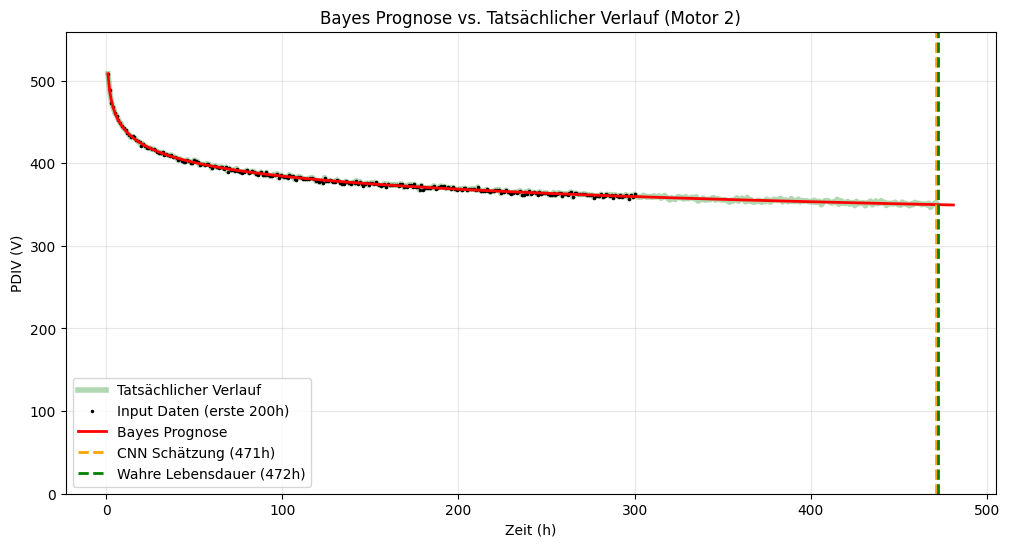

In [19]:
#Plotten 

#Zeitachse 
max_time_horizon = int(max(cnn_predicted_lifetime, y_test[sample_idx].item())) + 10
t_future = np.arange(1, max_time_horizon)
#Bayes Prognose-Kurve
predicted_curve = inverse_power_model(t_future, K_median, n_median)

#Echte Kurve aus den Testdaten, (die restlichen 80%)
true_full_curve = curves_test[sample_idx]
t_true = np.arange(1, len(true_full_curve) + 1)

plt.figure(figsize=(12,6))

#Wahre gesamte Daten plotten
plt.plot(t_true, true_full_curve, color="green", alpha=0.3, linewidth=4, label="Tatsächlicher Verlauf")
#Daten der ersten 200h (Input) plotten 
plt.plot(t_observed, input_seq_real, "k.", markersize=3, label="Input Daten (erste 200h)")
#Bayeds Vorhersage plloten 
plt.plot(t_future, predicted_curve, "r-", linewidth=2, label="Bayes Prognose")

#Vertikalte Linien für Lebensdauer
plt.axvline(x=cnn_predicted_lifetime, color="orange", linestyle="--", linewidth=2, label= f"CNN Schätzung ({int(cnn_predicted_lifetime)}h)")
plt.axvline(x=y_test[sample_idx].item(), color="green", linestyle="--", linewidth=2, label= f"Wahre Lebensdauer ({int(y_test[sample_idx].item())}h)")

plt.xlabel('Zeit (h)')
plt.ylabel('PDIV (V)')
plt.title(f'Bayes Prognose vs. Tatsächlicher Verlauf (Motor {sample_idx})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, max(input_seq_real)*1.1) # Y-Achse anpassen
plt.show()

In [20]:
[500, 0.03] + np.random.randn(32, 2)

array([[ 4.99980769e+02, -7.03554368e-01],
       [ 5.00405587e+02, -2.51690952e-02],
       [ 5.01487348e+02,  3.34327433e-01],
       [ 4.98392095e+02,  4.11103014e-01],
       [ 4.98605309e+02,  2.10453114e-01],
       [ 4.99256465e+02,  1.25119777e-01],
       [ 5.00936351e+02,  2.44677884e-01],
       [ 5.00496354e+02,  1.24325616e+00],
       [ 5.00383043e+02,  1.67343672e-02],
       [ 4.99410837e+02, -6.78450988e-01],
       [ 4.99864010e+02,  1.11281522e-01],
       [ 4.99445160e+02,  3.15387686e-02],
       [ 5.00987662e+02, -4.92916000e-01],
       [ 5.01148836e+02, -6.63714542e-02],
       [ 5.02460467e+02, -2.18191694e+00],
       [ 5.00301113e+02, -7.36427307e-01],
       [ 5.01546975e+02,  1.09543914e-01],
       [ 4.98760359e+02,  5.37848673e-01],
       [ 5.01097402e+02, -6.88538808e-01],
       [ 5.00473402e+02,  5.10592088e-01],
       [ 4.99603625e+02,  9.74829661e-01],
       [ 4.99066094e+02, -6.88348132e-01],
       [ 5.00519888e+02,  7.37820833e-01],
       [ 5.

In [21]:
noise_lvl = np.random.uniform(1.0, 3.0)

In [22]:
noise_lvl

2.8409835859597257

In [23]:
noise_ = np.random.normal(0,noise_lvl, size=pdiv_curve_1.shape )

NameError: name 'pdiv_curve_1' is not defined

In [ ]:
noise_

In [ ]:
t = np.linspace(1, 400, 400)
pdiv_curve_1 = inverse_power_model(t, 500, 0.014)


In [ ]:
pdiv_curve_1

In [ ]:
pdiv_curve_1 + noise_